In [39]:
# import libraries
import pickle
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [12]:
input_csv = "corona_tested_individuals_ver_006.english.csv"
pickle_file = "models/HistGradientBoostingClassifierModel_small.pkl"

In [13]:
def assess_model(model, name, X, y, threshold=0.5):
    name = f'{name}_threshold={threshold:.2f}'
    print(f'============= ASSESS: {name} ============')
    y_proba = model.predict_proba(X)[:, 1]
    print(f'calculate y_pred for {name}')
    y_pred = (y_proba >= threshold).astype(int)
    print_results(y, y_pred, name)
    plot_roc(y, y_proba, name, threshold)

In [14]:
def print_results(y_true, y_pred, model_name):
    y_names = ['negative', 'positive']
    print(f"=== Classification Report for {model_name}===")
    print(classification_report(y_true, y_pred, target_names=y_names))
    plot_confusion_matrix(y_true, y_pred, y_names, model_name)

In [15]:
def plot_confusion_matrix(y_true, y_pred, labels, model_name):
    print(f"=== Confusion Matrix {model_name}===")
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    print(f"True Negatives  (Correctly negative):          {((cm[0][0])*100):.2f} %")
    print(f"False Positives (Healthy flagged as positive): {((cm[0][1])*100):.2f} %")
    print(f"False Negatives (Missed positive):             {((cm[1][0])*100):.2f} %")
    print(f"True Positives  (Correctly positive):          {((cm[1][1])*100):.2f} %")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    # plot
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax)
    plt.title(f'{model_name}', fontsize=12, pad=15)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

In [16]:
def plot_roc(y_true, y_probability, model_name, threshold):
    auc = roc_auc_score(y_true, y_probability)
    print(f"ROC AUC Score {model_name}: {auc:.4f}")
    fpr_all, tpr_all, thresholds_all = roc_curve(y_true, y_probability, pos_label=1)
    # find fpr and tpr at threshold
    closest_idx = np.argmin(np.abs(thresholds_all - threshold))
    chosen_fpr = fpr_all[closest_idx]
    chosen_tpr = tpr_all[closest_idx]
    # Plot the ROC curve
    plt.figure(figsize=(7, 5))
    plt.plot(fpr_all, tpr_all, color='steelblue', lw=2, label=f'{model_name} (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
    plt.scatter(
        chosen_fpr, chosen_tpr,
        color='crimson', s=100, zorder=5,
        label=f'Threshold = {threshold:.2f}'
    )
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {model_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

In [30]:
def plot_features_grouped_by_target(df):
    target_col = 'corona_result'
    feature_cols = ['cough','fever', 'sore_throat','shortness_of_breath', 'head_ache', 'age_60_and_above', 'gender', 'test_indication']

    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(14, 8))
    plot_df = df[feature_cols + [target_col]].copy()
    plot_df[target_col] = plot_df[target_col].map({0: 'Negative', 1: 'Positive'})
    axes_flat = axes.flatten()
    for i, col in enumerate(feature_cols):
        ax = axes_flat[i]
        sns.countplot(
            data=plot_df,
            x=col,
            hue=target_col,
            ax=ax,
        )
        ax.set_title(f'Raw Count: "{col}"', fontsize=12, weight='bold', pad=10)
        ax.set_xlabel('')
        ax.set_ylabel('Cases', fontsize=10)
        ax.tick_params(axis='x', rotation=30)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

        ax.legend(title='Corona Result', loc='upper right')

    plt.suptitle('Feature Distribution', fontsize=16, weight='bold', y=0.99)
    plt.tight_layout()
    plt.show()

In [18]:
def hyper_parameter_tuning(X_train, y_train,estimator):
    param_grid = {
        'class_weight': [
            {0: 1, 1: 12},
            {0: 1, 1: 8},
            {0: 1, 1: 4},
            {0: 1, 1: 2}],
        'learning_rate': [0.001, 0.01, 0.1],
        'max_depth': [3,5,8],
        'max_iter': [100, 200, 300],
        'max_leaf_nodes': [15, 31, 50],
        'min_samples_leaf': [20, 50, 75],
    }
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=24)

    scoring = 'f1'
    grid_search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=20,
        scoring=scoring,
        cv=cv_strategy,
        n_jobs=-1,
        verbose=2,
    )
    print(f"Starting Grid Search against '{scoring}' scoring")
    grid_search.fit(X_train, y_train)

    print("=== Grid Search Complete ===")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best Cross-Validation '{scoring}' score: {grid_search.best_score_:.4f}")
    return grid_search

In [19]:
    # THIS FUNCTION IS DIRECTLY FROM GOOGLE AI
import numpy as np
from sklearn.metrics import precision_recall_curve
def get_optimal_threshold(model, X_val, y_val):
    """
    Finds the decision threshold that maximizes the F1-score
    using the precision-recall curve on validation data.
    """
    # 1. Get predicted probabilities for the positive class
    y_proba = model.predict_proba(X_val)[:, 1]

    # 2. Calculate precisions, recalls, and thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)

    # 3. Calculate F1-scores for each threshold point
    # Add a tiny epsilon (1e-10) to prevent division by zero errors
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    # 4. Find the index of the highest F1-score
    best_idx = np.argmax(f1_scores)

    # precision_recall_curve returns one more value for precision/recall than thresholds,
    # so we handle the edge case where the best index lands on the last element.
    if best_idx >= len(thresholds):
        best_threshold = 0.5  # Fallback to default if out of bounds
    else:
        best_threshold = thresholds[best_idx]

    print(f"--- Threshold Tuning Optimization ---")
    print(f"Optimal Threshold: {best_threshold:.4f}")
    print(f"Expected Val Precision: {precisions[best_idx]:.4f}")
    print(f"Expected Val Recall: {recalls[best_idx]:.4f}")
    print(f"Expected Val F1-Score: {f1_scores[best_idx]:.4f}\n")

    return best_threshold

IndentationError: expected an indented block after function definition on line 4 (3992956215.py, line 5)

In [32]:
# read in data
df = pd.read_csv(f"data/{input_csv}", low_memory=False)

In [33]:
# before cleaning
print('========= Before cleaning ==========')
print(df.info())

========= Before cleaning ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  object 
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  object 
 7   age_60_and_above     151528 non-null  object 
 8   gender               259285 non-null  object 
 9   test_indication      278848 non-null  object 
dtypes: float64(5), object(5)
memory usage: 21.3+ MB
None


In [34]:
print('========= Clean Data ==========')
# strip out 'other' results
df = df[df["corona_result"] != "other"]
# data string to datetime
df['test_date'] = pd.to_datetime(df['test_date'])
# results column to 0 or 1
df['corona_result'] = df['corona_result'].map({'positive': 1, 'negative': 0}).astype('Int64')
# assign other string columns to category
# Find all string columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f'The following columns will be changed to categories: {cat_cols}')
# Convert them to 'category' type
for col in cat_cols:
    df[col] = df[col].astype('category')
df = df.drop(columns=['test_date'])
print('====== After cleaning ======')
print(df.info())

========= Clean Data ==========
The following columns will be changed to categories: ['age_60_and_above', 'gender', 'test_indication']
====== After cleaning ======
<class 'pandas.core.frame.DataFrame'>
Index: 274956 entries, 0 to 278847
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   cough                274704 non-null  float64 
 1   fever                274704 non-null  float64 
 2   sore_throat          274955 non-null  float64 
 3   shortness_of_breath  274955 non-null  float64 
 4   head_ache            274955 non-null  float64 
 5   corona_result        274956 non-null  Int64   
 6   age_60_and_above     149292 non-null  category
 7   gender               255911 non-null  category
 8   test_indication      274956 non-null  category
dtypes: Int64(1), category(3), float64(5)
memory usage: 15.7 MB
None


====== Feature spread ======


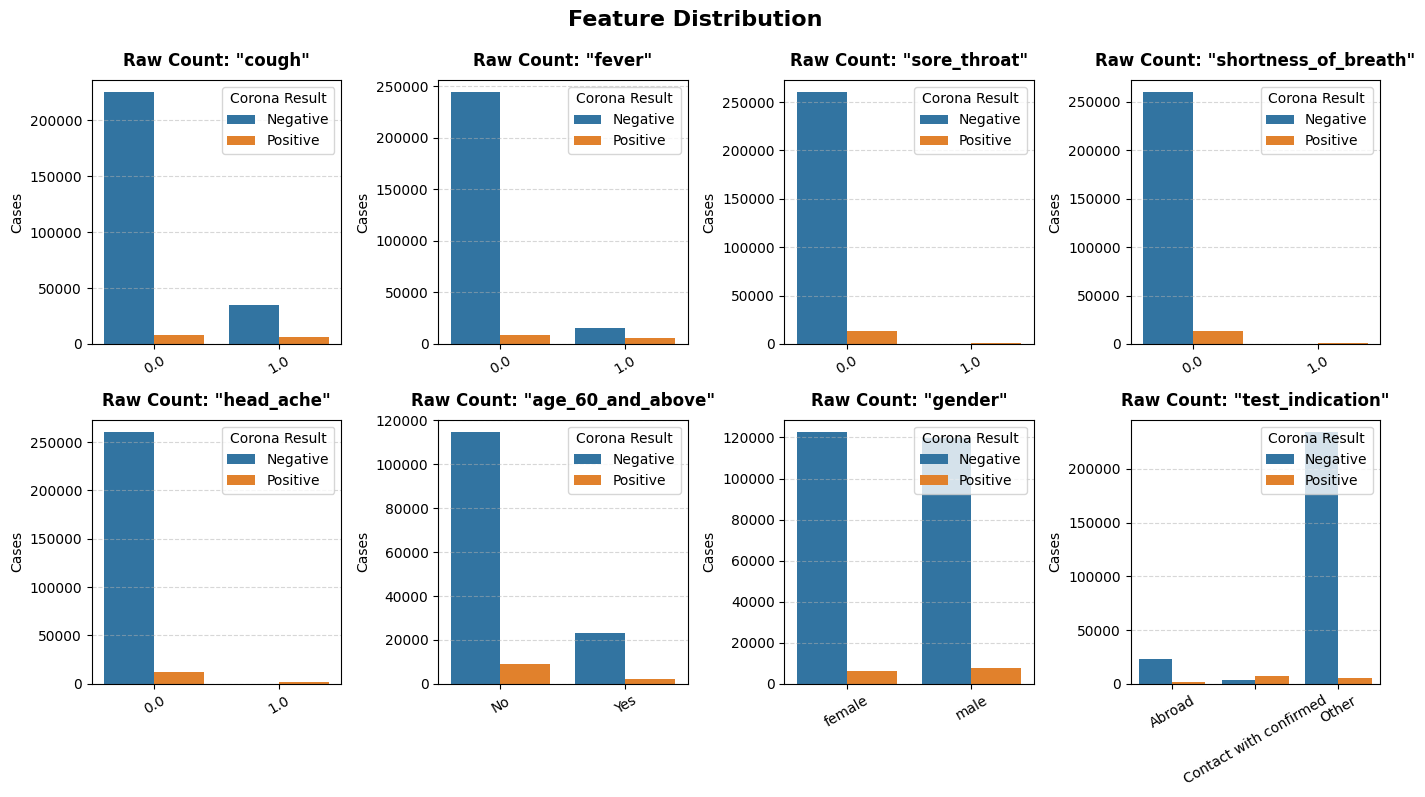

In [35]:
print('====== Feature spread ======')
plot_features_grouped_by_target(df)

In [36]:
X = df.drop(columns=['corona_result'])
y = df['corona_result']

y_neg = y.value_counts()[0]
y_pos = y.value_counts()[1]

print(f"Positive Cases: {y_pos}")
print(f"Negative Cases: {y_neg}")
print(f"Imbalance Ratio: 1 positive to {y_neg / y_pos:.1f} negatives")
print('data set is imbalanced')

Positive Cases: 14729
Negative Cases: 260227
Imbalance Ratio: 1 positive to 17.7 negatives
data set is imbalanced


In [37]:
# train test val split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify= df['corona_result'], test_size=0.2, random_state=24)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, stratify= y_test, test_size=0.2, random_state=24)

baseline_gb_classifier = HistGradientBoostingClassifier(
    categorical_features="from_dtype",
    class_weight='balanced',
    early_stopping=True,
    random_state=24
)

Fitting baseline model....
============= ASSESS: baseline_gb_classifier_train_threshold=0.50 ============
calculate y_pred for baseline_gb_classifier_train_threshold=0.50
=== Classification Report for baseline_gb_classifier_train_threshold=0.50===
              precision    recall  f1-score   support

    negative       0.99      0.93      0.96    208181
    positive       0.38      0.80      0.52     11783

    accuracy                           0.92    219964
   macro avg       0.68      0.86      0.74    219964
weighted avg       0.96      0.92      0.93    219964

=== Confusion Matrix baseline_gb_classifier_train_threshold=0.50===
True Negatives  (Correctly negative):          92.70 %
False Positives (Healthy flagged as positive): 7.30 %
False Negatives (Missed positive):             20.33 %
True Positives  (Correctly positive):          79.67 %


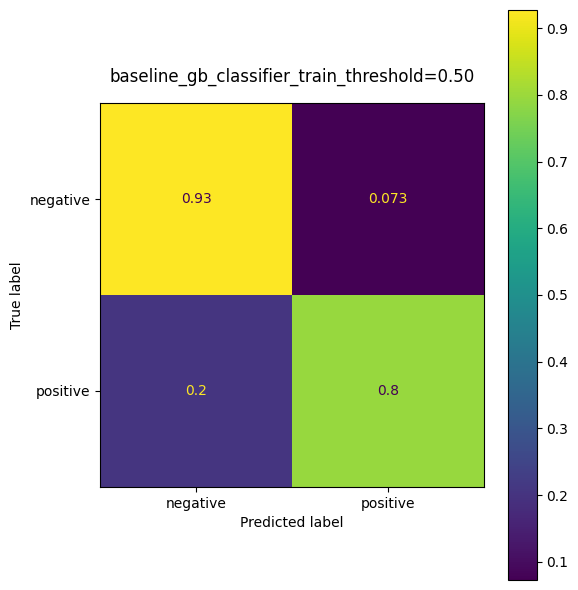

ROC AUC Score baseline_gb_classifier_train_threshold=0.50: 0.9098


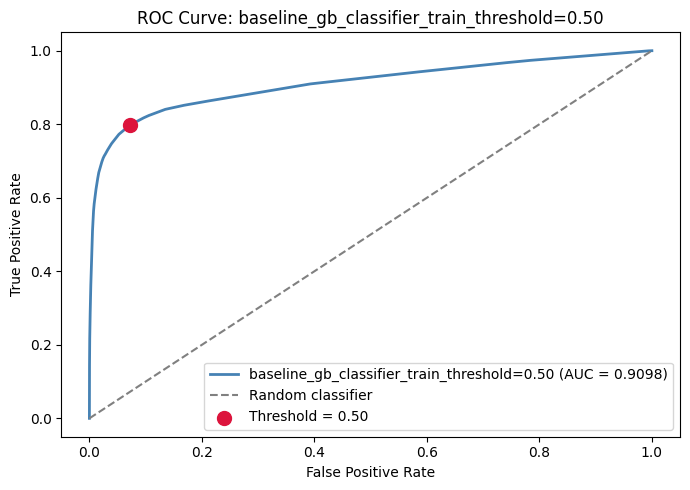

============= ASSESS: baseline_gb_classifier_test_threshold=0.50 ============
calculate y_pred for baseline_gb_classifier_test_threshold=0.50
=== Classification Report for baseline_gb_classifier_test_threshold=0.50===
              precision    recall  f1-score   support

    negative       0.99      0.93      0.96     41636
    positive       0.38      0.80      0.52      2357

    accuracy                           0.92     43993
   macro avg       0.69      0.86      0.74     43993
weighted avg       0.96      0.92      0.93     43993

=== Confusion Matrix baseline_gb_classifier_test_threshold=0.50===
True Negatives  (Correctly negative):          92.74 %
False Positives (Healthy flagged as positive): 7.26 %
False Negatives (Missed positive):             20.15 %
True Positives  (Correctly positive):          79.85 %


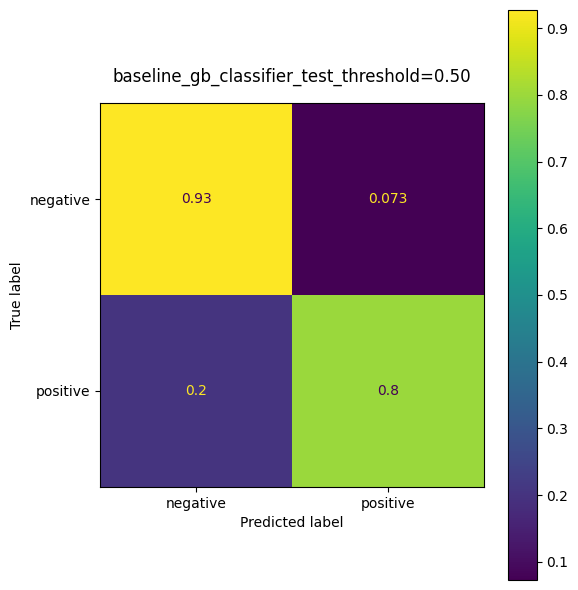

ROC AUC Score baseline_gb_classifier_test_threshold=0.50: 0.9108


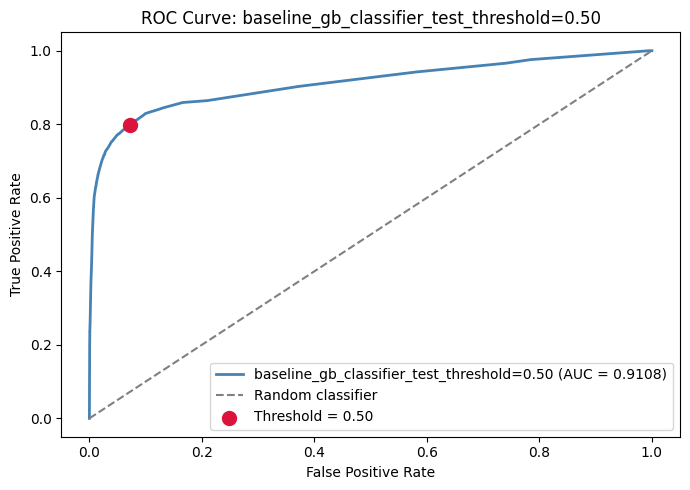

In [40]:
print('Fitting baseline model....')
baseline_gb_classifier.fit(X_train, y_train)
assess_model(baseline_gb_classifier,"baseline_gb_classifier_train", X_train, y_train)
assess_model(baseline_gb_classifier,"baseline_gb_classifier_test", X_test, y_test)

In [ ]:
print('Hyper parameter tuning....')
grid_search_CV = hyper_parameter_tuning(X_train= X_train, y_train= y_train, estimator=baseline_gb_classifier)
best_model = grid_search_CV.best_estimator_
best_thresh = get_optimal_threshold(best_model, X_val, y_val)
assess_model(best_model,"best_gb_classifier_train", X_train, y_train, threshold=best_thresh)
assess_model(best_model,"best_gb_classifier_test", X_test, y_test, threshold=best_thresh)
assess_model(best_model,"best_gb_classifier_test", X_test, y_test, threshold=0.3)
assess_model(best_model,"best_gb_classifier_test", X_test, y_test, threshold=0.6)

Hyper parameter tuning....
Starting Grid Search against 'f1' scoring
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END class_weight={0: 1, 1: 12}, learning_rate=0.01, max_depth=3, max_iter=100, max_leaf_nodes=15, min_samples_leaf=75; total time=   2.5s
[CV] END class_weight={0: 1, 1: 12}, learning_rate=0.01, max_depth=3, max_iter=100, max_leaf_nodes=15, min_samples_leaf=75; total time=   2.5s
[CV] END class_weight={0: 1, 1: 12}, learning_rate=0.01, max_depth=3, max_iter=100, max_leaf_nodes=15, min_samples_leaf=75; total time=   2.6s
[CV] END class_weight={0: 1, 1: 12}, learning_rate=0.01, max_depth=3, max_iter=100, max_leaf_nodes=15, min_samples_leaf=75; total time=   2.5s
[CV] END class_weight={0: 1, 1: 12}, learning_rate=0.01, max_depth=3, max_iter=100, max_leaf_nodes=15, min_samples_leaf=75; total time=   2.5s
[CV] END class_weight={0: 1, 1: 12}, learning_rate=0.1, max_depth=8, max_iter=300, max_leaf_nodes=15, min_samples_leaf=75; total time=   3.4s
[CV] END cla

In [ ]:
with open(pickle_file, 'wb') as file:
    pickle.dump(best_model, file)
print(f"Model pickled to {pickle_file} successfully")